# Historical Stock Data

### Problem statement : 
##### Scrape one stock and its prices from 2015-2020 from investing.com                                                                                                                               

### Approach : 
##### This program is using an artificial  recurrent neural network algorithm called Long Short Term Memory (LSTM). Predicting the next 3 months closing stock price of " Alembic Pharma Limited " using the historical data of 90 days interval from 2015-2020 from investing.com

In [1]:
#pip install investpy

In [2]:
import investpy

### Checkpoint 1

In [3]:
df = investpy.get_stock_historical_data(stock='ALEM',
                                        country='India',
                                        from_date='01/01/2015',
                                        to_date='01/01/2020')
print(df)

              Open    High     Low   Close  Volume Currency
Date                                                       
2015-01-01  447.60  450.00  440.00  445.20   46955      INR
2015-01-02  447.80  458.90  446.00  457.10  109741      INR
2015-01-05  460.00  460.00  452.00  454.60   53334      INR
2015-01-06  452.75  458.50  445.00  449.65   96448      INR
2015-01-07  445.35  458.45  445.15  450.95   82908      INR
...            ...     ...     ...     ...     ...      ...
2019-12-26  549.00  555.00  545.05  546.05   20347      INR
2019-12-27  545.50  569.95  545.50  565.65   53365      INR
2019-12-30  565.95  581.05  565.65  576.85   49776      INR
2019-12-31  576.85  595.00  568.00  571.30   64864      INR
2020-01-01  575.80  575.80  547.45  550.70   35709      INR

[1234 rows x 6 columns]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Checkpoint 2

In [5]:
Df = pd.DataFrame(df)

In [6]:
Df

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2015-01-01,447.60,450.00,440.00,445.20,46955,INR
2015-01-02,447.80,458.90,446.00,457.10,109741,INR
2015-01-05,460.00,460.00,452.00,454.60,53334,INR
2015-01-06,452.75,458.50,445.00,449.65,96448,INR
2015-01-07,445.35,458.45,445.15,450.95,82908,INR
...,...,...,...,...,...,...
2019-12-26,549.00,555.00,545.05,546.05,20347,INR
2019-12-27,545.50,569.95,545.50,565.65,53365,INR
2019-12-30,565.95,581.05,565.65,576.85,49776,INR


In [7]:
Df = Df.iloc[:,3:4]
Df

,Close
Date,
2015-01-01,445.20
2015-01-02,457.10
2015-01-05,454.60
2015-01-06,449.65
2015-01-07,450.95
...,...
2019-12-26,546.05
2019-12-27,565.65
2019-12-30,576.85


In [8]:
Df=Df.rename(columns={"Close":"Price"})

In [9]:
Df

,Price
Date,
2015-01-01,445.20
2015-01-02,457.10
2015-01-05,454.60
2015-01-06,449.65
2015-01-07,450.95
...,...
2019-12-26,546.05
2019-12-27,565.65
2019-12-30,576.85


In [10]:
# Get the no. of rows and columns
Df.shape

(1234, 1)

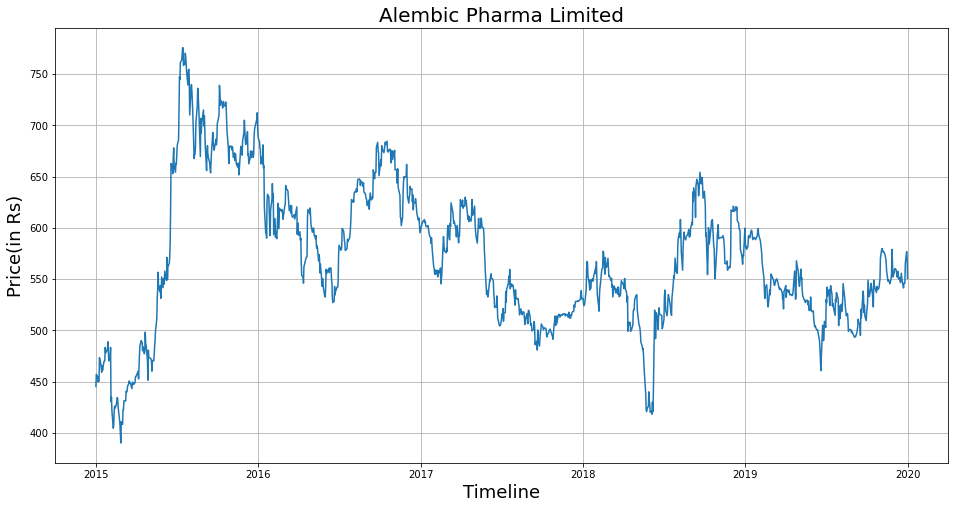

In [11]:
# Visualize the closing price history
plt.figure(figsize= (16,8))
plt.title('Alembic Pharma Limited',fontsize=20)
plt.plot(Df['Price'])
plt.xlabel('Timeline',fontsize=18)
plt.ylabel('Price(in Rs)',fontsize=18)
plt.grid()
plt.show()

### Checkpoint 3

In [12]:
# Convert the dataframe to numpy array 
unscaled_data = Df.values

# Get the no. of rows to train the model on
import math
training_data_len = math.ceil(len(unscaled_data)*0.8)

In [13]:
training_data_len

988

In [14]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(unscaled_data)

scaled_data

array([[0.14307932],
       [0.17392431],
       [0.16744427],
       ...,
       [0.4843183 ],
       [0.46993261],
       [0.41653707]])

In [15]:
# Creating the training data set

# Creating the scaled training data set
train_data = scaled_data[0:training_data_len,:]

#Split the data into x_train & y_train datasets
x_train =[]
y_train =[]

for i in range(90,len(train_data)):
    x_train.append(train_data[i-90:i,0])
    y_train.append(train_data[i,0])
    if i <= 90 :
        print(x_train)        # x_train contains the first 90 values 
        print(y_train)        # y_train contains the 91st value that we want our model to predict
        print()

[array([0.14307932, 0.17392431, 0.16744427, 0.15461379, 0.15798341,
       0.1566874 , 0.21617418, 0.20075168, 0.18921721, 0.17910835,
       0.19517885, 0.18390358, 0.20541731, 0.20800933, 0.20800933,
       0.24196475, 0.22770866, 0.23691032, 0.25622084, 0.23004147,
       0.20762053, 0.21539658, 0.24183515, 0.10432867, 0.11625194,
       0.08203733, 0.03758424, 0.04237947, 0.07918611, 0.0933126 ,
       0.08825816, 0.09694142, 0.11521514, 0.11158631, 0.09110938,
       0.06013478, 0.05002592, 0.02566096, 0.        , 0.05378434,
       0.0473043 , 0.08359253, 0.08307413, 0.10705029, 0.10614308,
       0.13076724, 0.12856402, 0.13024883, 0.14269051, 0.15111457,
       0.1569466 , 0.15202177, 0.15215137, 0.15033696, 0.13763608,
       0.15344738, 0.15422499, 0.14994816, 0.14826335, 0.15254018,
       0.16744427, 0.16770347, 0.18157076, 0.16226024, 0.19660446,
       0.22330223, 0.24611198, 0.25920166, 0.25375842, 0.23354069,
       0.24351996, 0.22576464, 0.23315189, 0.28045619, 0.2525

In [16]:
# Checking for i <= 91

train_data = scaled_data[0:training_data_len,:]

#Split the data into x_train & y_train datasets
x_train =[]
y_train =[]

for i in range(90,len(train_data)):
    x_train.append(train_data[i-90:i,0])
    y_train.append(train_data[i,0])
    if i <= 91 :
        print(x_train)
        print(y_train)
        print()

[array([0.14307932, 0.17392431, 0.16744427, 0.15461379, 0.15798341,
       0.1566874 , 0.21617418, 0.20075168, 0.18921721, 0.17910835,
       0.19517885, 0.18390358, 0.20541731, 0.20800933, 0.20800933,
       0.24196475, 0.22770866, 0.23691032, 0.25622084, 0.23004147,
       0.20762053, 0.21539658, 0.24183515, 0.10432867, 0.11625194,
       0.08203733, 0.03758424, 0.04237947, 0.07918611, 0.0933126 ,
       0.08825816, 0.09694142, 0.11521514, 0.11158631, 0.09110938,
       0.06013478, 0.05002592, 0.02566096, 0.        , 0.05378434,
       0.0473043 , 0.08359253, 0.08307413, 0.10705029, 0.10614308,
       0.13076724, 0.12856402, 0.13024883, 0.14269051, 0.15111457,
       0.1569466 , 0.15202177, 0.15215137, 0.15033696, 0.13763608,
       0.15344738, 0.15422499, 0.14994816, 0.14826335, 0.15254018,
       0.16744427, 0.16770347, 0.18157076, 0.16226024, 0.19660446,
       0.22330223, 0.24611198, 0.25920166, 0.25375842, 0.23354069,
       0.24351996, 0.22576464, 0.23315189, 0.28045619, 0.2525

In [17]:
# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train),np.array(y_train)

In [18]:
#Reshape the data
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_train.shape

(898, 90, 1)

In [19]:
#pip install keras

In [20]:
#pip install tensorflow

In [21]:

# Build the LSTM model

from keras.models import Sequential
from keras.layers import Dense , LSTM
model = Sequential()
model.add(LSTM(50,return_sequences = True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(50,return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))

In [22]:
# Compile the model
model.compile(optimizer='adam',loss='mean_squared_error')

In [23]:
# Train the model
model.fit(x_train,y_train,batch_size=1,epochs=1)

898/898 [==============================] - 36s 23ms/step - loss: 0.0174


In [24]:
#Create the testing data set 
#Create a new array containing scaled values fromindex 898 to last
test_data = scaled_data[training_data_len - 90 : , :]

#Create the data sets x_test and y_test
x_test =[]
y_test = unscaled_data[training_data_len:,:]
for i in range (90,len(test_data)):
    x_test.append(test_data[i-90:i,0])

In [25]:
#Convert the data to a numpy array
x_test = np.array(x_test)

In [26]:
#Reshape the data
x_test= np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [27]:
#Get the models predicted price values 
predictions= model.predict(x_test)
predictions= scaler.inverse_transform(predictions)

In [28]:
#Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(predictions - y_test)**2)
rmse

0.2596349452569237

<ipython-input-29-68719c8c2cee>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions']=predictions


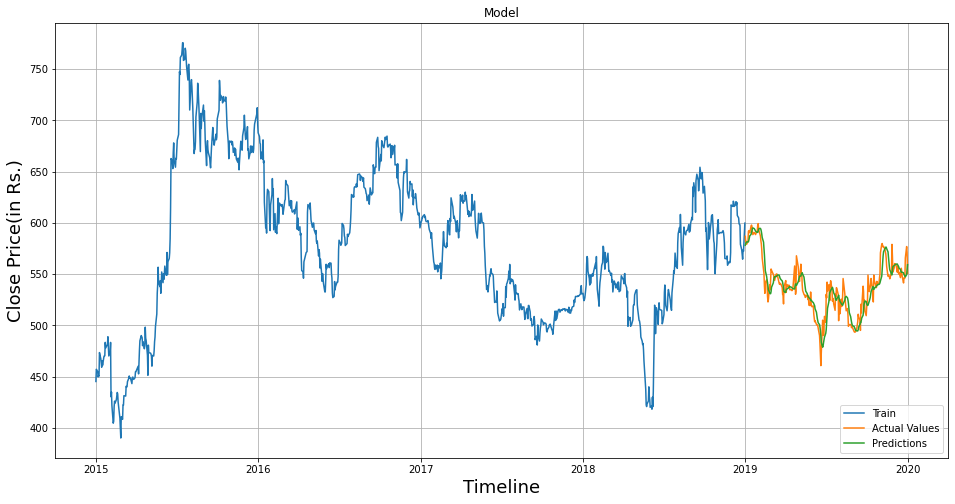

In [29]:
#Plot the data
train = Df[:training_data_len]
valid = Df[training_data_len:]
valid['Predictions']=predictions

#Visualize the data
plt.figure(figsize = (16,8))
plt.grid()
plt.title('Model')
plt.xlabel('Timeline',fontsize=18)
plt.ylabel('Close Price(in Rs.)',fontsize=18)
plt.plot(train['Price'])
plt.plot(valid[['Price','Predictions']])
plt.legend(['Train','Actual Values','Predictions'],loc='lower right')
plt.show()

In [30]:
#Show the valid and predicted prices
valid

,Price,Predictions
Date,,
2019-01-01,586.85,578.133362
2019-01-02,580.45,579.860657
2019-01-03,581.90,580.728943
2019-01-04,579.10,581.335449
2019-01-07,581.90,581.330017
...,...,...
2019-12-26,546.05,548.238098
2019-12-27,565.65,547.278076
2019-12-30,576.85,549.416626


In [31]:
#Get the quote
alem_quote1 = investpy.get_stock_historical_data(stock='ALEM',country='India',from_date='01/01/2015',to_date='01/01/2020')

#Create a new dataframe
new_df = alem_quote1.filter(['Close'])    # using filter which is alternative to iloc

#Get the last 3 months(say 90 days) closing price values and convert the dataframe to an array
last_90_days = new_df[-90:].values

#Scale the data to be values between 0 and 1
last_90_days_scaled= scaler.transform(last_90_days)

#Create an empty list
X_test = []

#Append the past 90 days
X_test.append(last_90_days_scaled)

#Convert the X_test data set to a numpy array 
X_test = np.array(X_test)

#Reshape the data 
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

#Get the predicted scaled price
pred_price = model.predict(X_test)

#undo the scaling
pred_price = scaler.inverse_transform(pred_price)

In [32]:
print(pred_price)

[[560.2902]]


In [33]:
#Get the quote
alem_quote2 = investpy.get_stock_historical_data(stock='ALEM',country='India',from_date='01/01/2020',to_date='01/03/2020')
print(alem_quote2['Close'])

Date
2020-01-01    550.70
2020-01-02    561.85
2020-01-03    563.65
2020-01-06    566.70
2020-01-07    556.55
2020-01-08    553.35
2020-01-09    558.25
2020-01-10    557.90
2020-01-13    558.75
2020-01-14    562.10
2020-01-15    565.95
2020-01-16    583.65
2020-01-17    601.65
2020-01-20    598.40
2020-01-21    599.60
2020-01-22    590.20
2020-01-23    588.80
2020-01-24    589.85
2020-01-27    614.60
2020-01-28    632.40
2020-01-29    634.55
2020-01-30    639.85
2020-01-31    630.70
2020-02-01    622.60
2020-02-03    624.05
2020-02-04    617.50
2020-02-05    625.10
2020-02-06    640.00
2020-02-07    645.55
2020-02-10    643.00
2020-02-11    649.15
2020-02-12    649.20
2020-02-13    639.15
2020-02-14    643.35
2020-02-17    644.00
2020-02-18    644.95
2020-02-19    674.60
2020-02-20    664.60
2020-02-24    650.55
2020-02-25    646.60
2020-02-26    647.55
2020-02-27    652.50
2020-02-28    629.95
Name: Close, dtype: float64
